# Creditcard FDS — 전처리 파이프라인 전 과정 (`fds_pipeline.py`와 동일)

**목표:** `fds_pipeline.py`가 하는 일을 **순서대로** 읽고, 각 단계의 **이유**와 **입·출력 형태**를 그래프·표로 확인합니다.

**필요 파일:** `dataset/creditcard.csv` (Kaggle [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud))

**이 노트북에서 다루는 범위**
1. 원시 CSV 로드 · 스키마 · 결측 · 클래스 비율  
2. **EDA(탐색):** 불균형, `Time`·`Amount` 분포 — *전처리 결정의 근거*  
3. **전처리(본 파이프라인):** `Time` → `Time_sin`/`Time_cos`, `Time` 제거, `Amount` `RobustScaler`, `X`·`y`  
4. **분할:** 층화 8:2 (`train_test_split`, `stratify=y`)  
5. **리샘플:** Train에만 `SMOTETomek` — Test는 원 불균형 유지  

학습·XGB·SHAP은 **전처리 튜토리얼 범위 밖**입니다. 동일 로직은 `train_xgb_pipeline()`에 있습니다.

맨 아래 **부록**에는 “최종 파이프라인만이 아니라, 신입 과제에서 보통 요구되는 탐색·의사결정”을 무엇으로 채우면 좋은지 정리해 두었습니다.


In [2]:
# --- 설정: 경로·폰트·import ---
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from fds_pipeline import (
    CSV_DEFAULT,
    RANDOM_STATE,
    TEST_SIZE,
    SECONDS_PER_DAY,
    preprocess_creditcard_dataframe,
    resample_train_smotetomek,
    stratified_train_test_split_creditcard,
)

sns.set_theme(style="whitegrid")


def setup_korean_font():
    candidates = [
        Path(r"C:\Windows\Fonts\malgun.ttf"),
        Path(r"C:\Windows\Fonts\malgunsl.ttf"),
    ]
    for font_path in candidates:
        if not font_path.is_file():
            continue
        try:
            font_manager.fontManager.addfont(str(font_path))
        except Exception:
            pass
        fp = font_manager.FontProperties(fname=str(font_path))
        name = fp.get_name()
        plt.rcParams["font.family"] = name
        plt.rcParams["font.sans-serif"] = [name, "Malgun Gothic", "DejaVu Sans"]
        return name
    plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "AppleGothic", "DejaVu Sans"]
    plt.rcParams["font.family"] = "sans-serif"
    return None


setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False
print("CSV_DEFAULT =", CSV_DEFAULT.resolve())
print("RANDOM_STATE =", RANDOM_STATE, "| TEST_SIZE =", TEST_SIZE, "| SECONDS_PER_DAY =", SECONDS_PER_DAY)


CSV_DEFAULT = D:\personalProject\dataset\creditcard.csv
RANDOM_STATE = 42 | TEST_SIZE = 0.2 | SECONDS_PER_DAY = 86400


## 0. 원시 데이터 로드

Kaggle 파일은 **한 줄 = 한 거래**, 컬럼은 대략 다음과 같습니다.
- `Time`: 첫 거래로부터의 **경과 시간(초)** (단조 증가에 가깝고, “시각”이 아님)
- `Amount`: 거래 금액
- `V1`…`V28`: PCA 등으로 **비식별화된** 수치 특성
- `Class`: 0=정상, 1=사기
- `df_raw.dtypes` : 데이터프레임의 모든 열(Columns)의 데이터 타입
- `.value_counts()` : 타입별 개수
- `isna()` : True=결측치, False=값 존재
- `.sum()` : 1번째 sum()은 열별 합계 구하기(위에서 아래로), 2번째 sum()은 전체 합계 구하기

In [3]:
if not CSV_DEFAULT.is_file():
    raise FileNotFoundError(
        f"{CSV_DEFAULT} 가 없습니다. Kaggle에서 받아 dataset/ 에 두세요."
    )

df_raw = pd.read_csv(CSV_DEFAULT)
print("shape (행, 열):", df_raw.shape)
print("dtypes:\n", df_raw.dtypes.value_counts())
print("\n결측 (열당):", df_raw.isna().sum().sum(), "건")
display_cols = ["Time", "Amount", "V1", "V2", "V28", "Class"]
print("\n샘플:")
df_raw[display_cols].head(8)


shape (행, 열): (284807, 31)
dtypes:
 float64    30
int64       1
Name: count, dtype: int64

결측 (열당): 0 건

샘플:


,Time,Amount,V1,V2,V28,Class
0,0.0,149.62,-1.359807,-0.072781,-0.021053,0
1,0.0,2.69,1.191857,0.266151,0.014724,0
2,1.0,378.66,-1.358354,-1.340163,-0.059752,0
3,1.0,123.50,-0.966272,-0.185226,0.061458,0
4,2.0,69.99,-1.158233,0.877737,0.215153,0
5,2.0,3.67,-0.425966,0.960523,0.081080,0
6,4.0,4.99,1.229658,0.141004,0.005168,0
7,7.0,40.80,-0.644269,1.417964,-1.085339,0


In [4]:
vc = df_raw["Class"].value_counts().sort_index()
ratio = vc / len(df_raw)
print("클래스 건수:\n", vc)
print("\n비율:\n", ratio.map(lambda x: f"{x:.4%}"))


클래스 건수:
 Class
0    284315
1       492
Name: count, dtype: int64

비율:
 Class
0    99.8273%
1     0.1727%
Name: count, dtype: object


### 그림: 클래스 불균형

사기(1) 비율이 매우 낮습니다. **정확도(Accuracy)**만 보면 “전부 정상으로 예측”해도 높게 나와 **착시**가 생깁니다. 그래서 이후 지표는 Recall, PR-AUC, F2 등을 함께 씁니다.


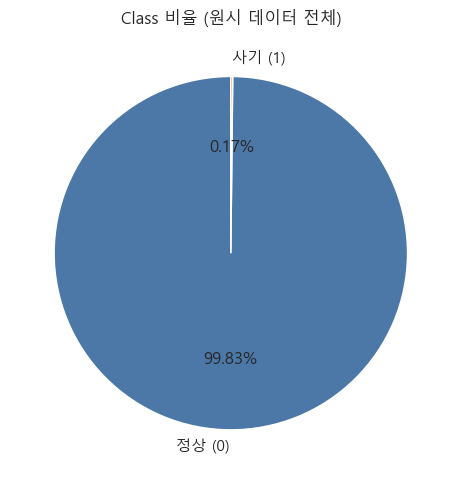

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
labels = ["정상 (0)", "사기 (1)"]
sizes = [vc[0], vc[1]]
ax.pie(sizes, labels=labels, autopct="%1.2f%%", startangle=90, colors=["#4C78A8", "#F58518"])
ax.set_title("Class 비율 (원시 데이터 전체)")
plt.tight_layout()
plt.show()


## 1. `Time` — 왜 그대로 쓰기 어렵고, sin/cos인가?

- 값은 **누적 초**라서 크기 자체에 의미가 있어, 트리가 **시간 순서·구간**에 과적합하기 쉽습니다.
- 금융 사기는 **하루 주기**(심야 등)와 연관될 수 있어, **0~86400초를 한 바퀴**로 보는 것이 자연스럽습니다.

파이프라인에서는 하루 길이 `SECONDS_PER_DAY = 86400`으로 나눈 뒤:

$$
\mathrm{Time\_sin} = \sin\left(\frac{2\pi \cdot \mathrm{Time}}{86400}\right),\quad
\mathrm{Time\_cos} = \cos\left(\frac{2\pi \cdot \mathrm{Time}}{86400}\right)
$$

원본 컬럼 `Time`은 **삭제**하고, 위 두 파생 변수만 남깁니다.


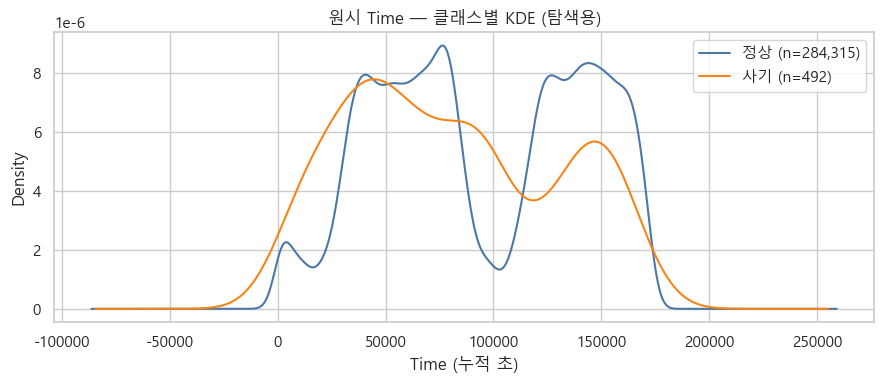

In [6]:
# 원시 Time 분포 (EDA — 클래스별 KDE)
fig, ax = plt.subplots(figsize=(9, 4))
for c, name, color in [(0, "정상", "#4C78A8"), (1, "사기", "#F58518")]:
    sub = df_raw.loc[df_raw["Class"] == c, "Time"]
    sub.plot(kind="kde", ax=ax, label=f"{name} (n={len(sub):,})", color=color)
ax.set_xlabel("Time (누적 초)")
ax.set_title("원시 Time — 클래스별 KDE (탐색용)")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# 수동으로 파생 변수 생성 (fds_pipeline.preprocess_creditcard_dataframe 과 동일 식)
t = df_raw["Time"].astype(float)
time_sin = np.sin(2 * np.pi * t / SECONDS_PER_DAY)
time_cos = np.cos(2 * np.pi * t / SECONDS_PER_DAY)

manual = pd.DataFrame({"Time_sin": time_sin, "Time_cos": time_cos})
print("Time_sin / Time_cos 요약:")
display(manual.describe())


Time_sin / Time_cos 요약:


,Time_sin,Time_cos
count,284807.000000,284807.000000
mean,-0.266787,-0.140733
std,0.628132,0.717268
min,-1.000000,-1.000000
25%,-0.841236,-0.837083
50%,-0.435624,-0.311920
75%,0.247422,0.597800
max,1.000000,1.000000


## 2. `Amount` — 왜 RobustScaler이며, 언제 fit하나?

- 금액은 **꼬리가 긴** 분포라 스케일이 튀면 학습에 불리합니다.
- `RobustScaler`는 중앙값·IQR 기반이라 **이상치에 상대적으로 강건**합니다.

**중요:** 이 프로젝트 구현에서는 **Train/Test 나누기 전**, 전체 `df`에 대해 `RobustScaler`를 **fit**합니다.  
(과제/보고서에 “train만 스케일”이라고 쓰면 **코드와 다릅니다**. 의도는 “극단 금액 스케일 왜곡 완화”입니다.)


C:\Users\human-28\AppData\Local\Temp\ipykernel_19764\3471633555.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([amt_orig[df_raw["Class"] == 0], amt_orig[df_raw["Class"] == 1]], labels=["정상", "사기"])


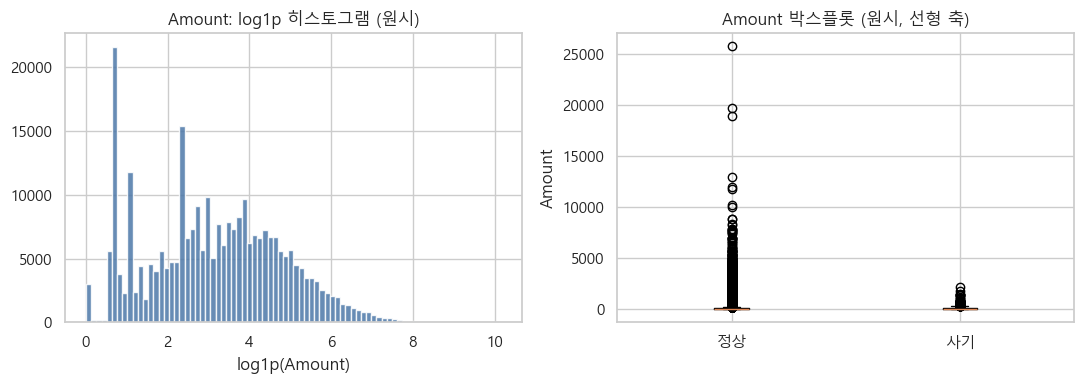

In [8]:
amt_orig = df_raw["Amount"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log1p(amt_orig), bins=80, color="#4C78A8", edgecolor="white", alpha=0.85)
axes[0].set_title("Amount: log1p 히스토그램 (원시)")
axes[0].set_xlabel("log1p(Amount)")

axes[1].boxplot([amt_orig[df_raw["Class"] == 0], amt_orig[df_raw["Class"] == 1]], labels=["정상", "사기"])
axes[1].set_title("Amount 박스플롯 (원시, 선형 축)")
axes[1].set_ylabel("Amount")
plt.tight_layout()
plt.show()


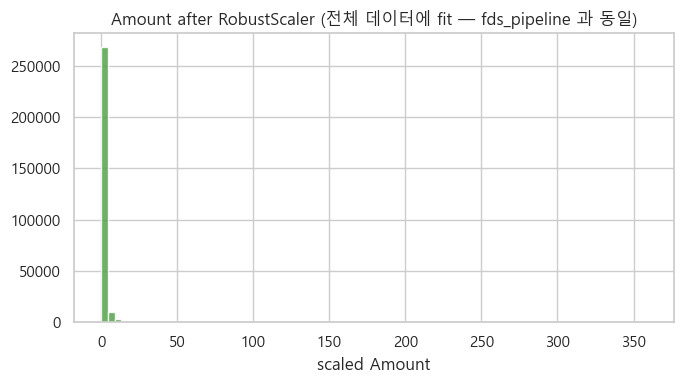

In [9]:
# 파이프라인과 동일: 전체 df에 대해 RobustScaler fit → Amount 치환
scaler_amount = RobustScaler()
amount_scaled = scaler_amount.fit_transform(amt_orig.values.reshape(-1, 1)).ravel()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(amount_scaled, bins=80, color="#54A24B", edgecolor="white", alpha=0.85)
ax.set_title("Amount after RobustScaler (전체 데이터에 fit — fds_pipeline 과 동일)")
ax.set_xlabel("scaled Amount")
plt.tight_layout()
plt.show()


## 3. `X`, `y` 조립 (전처리 함수 한 번에)

아래는 `preprocess_creditcard_dataframe(df_raw)`와 **같은 결과**를 만듭니다.

- `X`: `Class` 제외, 특성 열 **30개** (`V1`…`V28`, `Amount` 스케일됨, `Time_sin`, `Time_cos`)
- `y`: `Class`


In [10]:
X_full, y_full, scaler_from_fn = preprocess_creditcard_dataframe(df_raw)

# Amount: 함수 내부도 “전체 df에 새 RobustScaler fit”이므로, 동일 식으로 재현 가능한지 확인
_manual_amt = RobustScaler().fit_transform(df_raw["Amount"].astype(float).values.reshape(-1, 1)).ravel()
assert np.allclose(_manual_amt, X_full["Amount"].values)

print("X shape:", X_full.shape)
print("y shape:", y_full.shape)
print("\n특성 열 이름 (처음·끝):")
print(list(X_full.columns[:5]), "...", list(X_full.columns[-3:]))
print("\n타깃 분포 (전처리 후에도 건수 동일):", y_full.value_counts().to_dict())


X shape: (284807, 31)
y shape: (284807,)

특성 열 이름 (처음·끝):
['V1', 'V2', 'V3', 'V4', 'V5'] ... ['Amount', 'Time_sin', 'Time_cos']

타깃 분포 (전처리 후에도 건수 동일): {0: 284315, 1: 492}


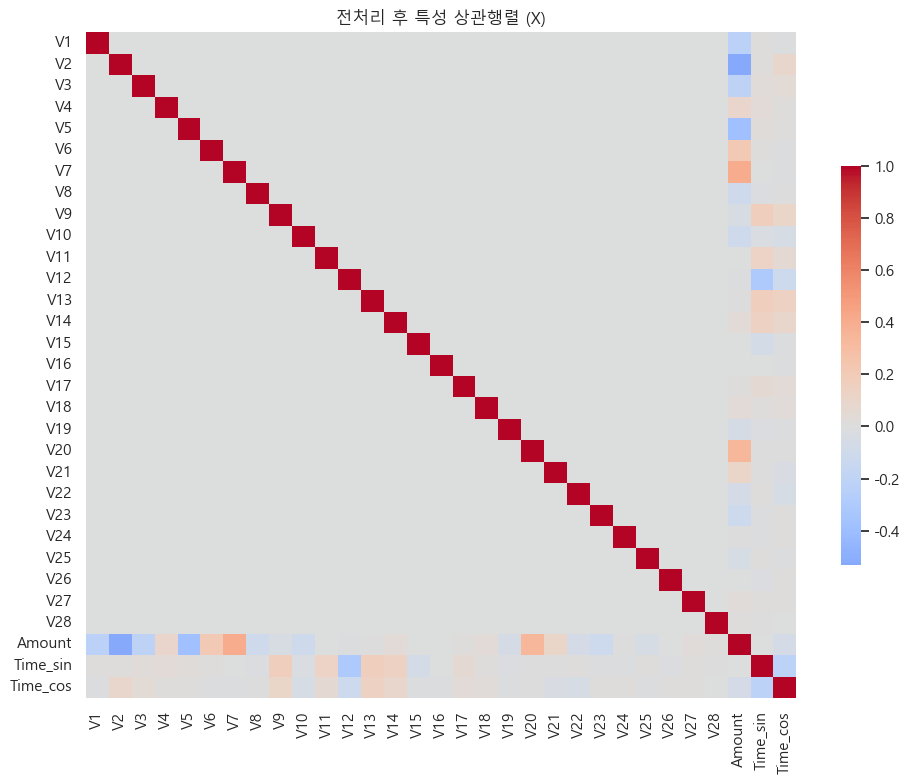

In [11]:
# 특성 상관 히트맵 (전처리 후 X — 참고용, 해석은 탐색 수준)
corr = X_full.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title("전처리 후 특성 상관행렬 (X)")
plt.tight_layout()
plt.show()


## 4. Train / Test 분할 (층화 8:2)

- `test_size=0.2`, `stratify=y`, `random_state=42`
- **Test에는 SMOTE를 쓰지 않습니다.** (실제 평가는 원 불균형에 가깝게 유지)


In [12]:
X_train, X_test, y_train, y_test = stratified_train_test_split_creditcard(X_full, y_full)

def counts(name, s):
    vc = s.value_counts().sort_index()
    return pd.Series({"정상": int(vc.get(0, 0)), "사기": int(vc.get(1, 0)), "합계": len(s)})

summary_split = pd.DataFrame({
    "Train": counts("t", y_train),
    "Test": counts("e", y_test),
})
print(summary_split)
print("\nTrain 사기 비율:", f"{y_train.mean():.4%}", "| Test 사기 비율:", f"{y_test.mean():.4%}")


     Train   Test
정상  227451  56864
사기     394     98
합계  227845  56962

Train 사기 비율: 0.1729% | Test 사기 비율: 0.1720%


## 5. Train만 SMOTETomek

- **SMOTE**류: 소수 클래스 주변에 합성 샘플을 추가  
- **Tomek links**: 경계의 노이즈 쌍을 정리해 **결정 경계**를 다소 깨끗하게  

`imblearn`의 `SMOTETomek`을 Train에만 적용합니다.


리샘플 전 Train:
 Class
0    227451
1       394
Name: count, dtype: int64

리샘플 후 Train:
 Class
0    227451
1    227451
Name: count, dtype: int64


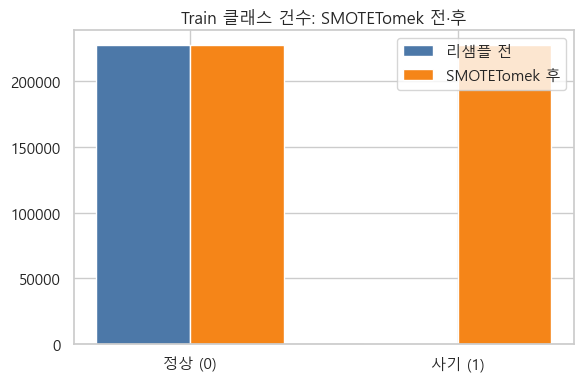

In [13]:
X_tr_res, y_tr_res = resample_train_smotetomek(X_train, y_train)

before = y_train.value_counts().sort_index()
after = pd.Series(y_tr_res).value_counts().sort_index()
print("리샘플 전 Train:\n", before)
print("\n리샘플 후 Train:\n", after)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
w = 0.35
ax.bar(x - w / 2, [before.get(0, 0), before.get(1, 0)], w, label="리샘플 전", color="#4C78A8")
ax.bar(x + w / 2, [after.get(0, 0), after.get(1, 0)], w, label="SMOTETomek 후", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(["정상 (0)", "사기 (1)"])
ax.set_title("Train 클래스 건수: SMOTETomek 전·후")
ax.legend()
plt.tight_layout()
plt.show()


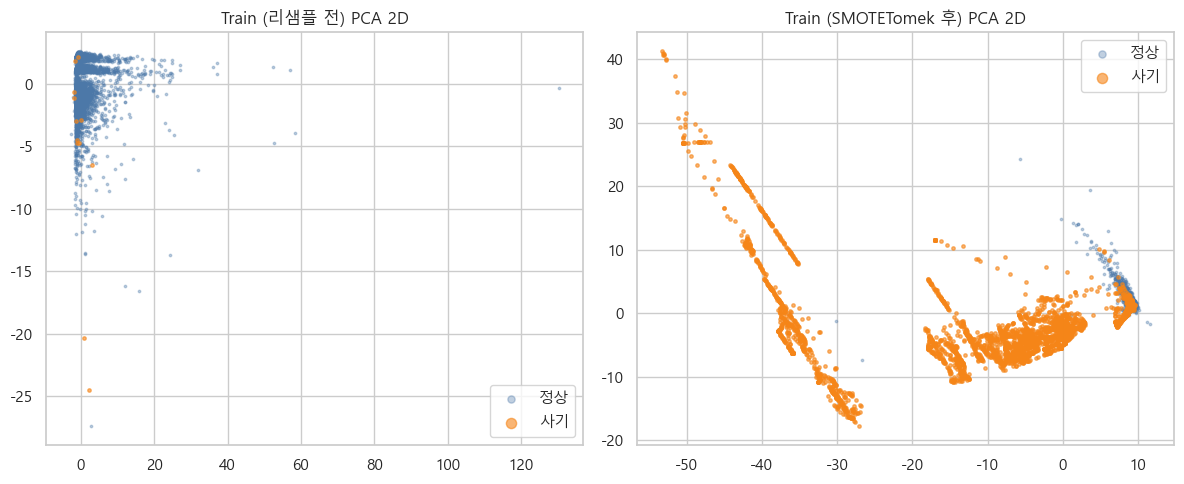

In [18]:
# PCA 2D로 Train 분포 스케치 (리샘플 전·후)
# 샘플 수가 많으면 시간이 걸리므로 최대 8000행만 사용
rng = np.random.default_rng(RANDOM_STATE)
n_plot = min(8000, len(X_train))


def subsample(X, y, n):
    if len(X) <= n:
        return X, y
    idx = rng.choice(len(X), size=n, replace=False)
    return X.iloc[idx], y.iloc[idx]


def pca2(X):
    p = PCA(n_components=2, random_state=RANDOM_STATE)
    z = p.fit_transform(X.values)
    return z, p


X_a, y_a = subsample(X_train, y_train, n_plot)
X_b, y_b = subsample(X_tr_res, pd.Series(y_tr_res), n_plot)

z_a, _ = pca2(X_a)
z_b, _ = pca2(X_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, z, yv, title in [
    (axes[0], z_a, y_a, "Train (리샘플 전) PCA 2D"),
    (axes[1], z_b, y_b, "Train (SMOTETomek 후) PCA 2D"),
]:
    m0 = yv == 0
    m1 = yv == 1
    ax.scatter(z[m0, 0], z[m0, 1], s=3, alpha=0.35, label="정상", c="#4C78A8")
    ax.scatter(z[m1, 0], z[m1, 1], s=6, alpha=0.6, label="사기", c="#F58518")
    ax.set_title(title)
    ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


## 6. 요약 표 — 무엇이 어디까지 적용되었나

| 단계 | 대상 | 내용 |
|------|------|------|
| 원시 CSV | 전체 | `read_csv` |
| `Time` 파생 | 전체 | `Time_sin`, `Time_cos` 후 `Time` 삭제 |
| `Amount` | 전체 | `RobustScaler` fit/transform (분할 **전**) |
| `X`, `y` | 전체 | 특성 30열, 타깃 `Class` |
| Train/Test | `X`, `y` | 8:2, 층화, `random_state=42` |
| SMOTETomek | **Train만** | Test는 **미적용** |

이후 `train_xgb_pipeline()`은 **리샘플된 Train**으로 XGBoost를 학습하고, **원 불균형 Test**로 평가합니다.


In [16]:
# 최종 검증: 같은 전처리·같은 random_state로 다시 분할하면 X_test·y_test가 재현되는지
X_chk, y_chk, _ = preprocess_creditcard_dataframe(df_raw)
tr_a, te_a, ytr_a, yte_a = stratified_train_test_split_creditcard(X_chk, y_chk)
assert np.array_equal(X_test.values, te_a.values)
assert np.array_equal(y_test.values, yte_a.values)
print("OK: preprocess + stratified split 이 동일하게 재현됩니다 (fds_pipeline과 일치).")
print("학습까지 확인하려면: from fds_pipeline import train_xgb_pipeline")
print("  model, X_te, y_te, sc = train_xgb_pipeline(CSV_DEFAULT)  # 데이터 크면 수 분 소요")


OK: preprocess + stratified split 이 동일하게 재현됩니다 (fds_pipeline과 일치).
학습까지 확인하려면: from fds_pipeline import train_xgb_pipeline
  model, X_te, y_te, sc = train_xgb_pipeline(CSV_DEFAULT)  # 데이터 크면 수 분 소요


## 부록 — 정답만이 아니라 **과정**을 보고서에 넣을 때

지금 노트북은 **`fds_pipeline.py`와 같은 최종 파이프라인**을 단계별로 보여 준다.  
실제 과제·현업에서는 **최종 코드만**이 아니라, 아래를 **시도했는지·왜 채택/배제했는지**가 있어야 “왜 이렇게 했는지”가 설득력 있다.

### 1. 데이터 품질·정의 (맨 앞 단계)
- **중복 행**, **결측** 패턴(이 Kaggle 세트는 결측이 거의 없지만, 다른 데이터에서는 여기서 막힌다).
- **타깃 정의**가 과제·도메인과 같은지(0/1 의미).
- **시간 컬럼 의미**를 한 번 확인: `Time`은 시계열 타임스탬프가 아니라 **경과 초**(§1과 연결).

### 2. 불균형·비용 가정
- **Accuracy만** 쓰면 왜 착시가 나는지 → **Recall / PR-AUC / F1 / F2** 중 무엇을 왜 볼지, **미탐 vs 헛탐** 비용을 한 문장이라도 연결.
- **불균형 처리 대안**: `class_weight`, `SMOTE`만, `SMOTETomek`, 언더샘플링 등.  
  **최종 선택**이 Train만 리샘플·Test 원 유지인 이유(평가는 실제 분포에 가깝게).

### 3. 스케일·누출(leakage) 논의
- **StandardScaler vs RobustScaler vs log 변환** 등을 **비교·근거** 한 번(꼬리·이상치).
- **스케일러를 Train에만 fit**할지 **전체에 fit**할지는 설계 선택이다. 이 프로젝트는 **분할 전 전체 df에 RobustScaler fit** — 보고서에는 **그렇게 구현했고, 대안과 트레이드오프**를 한 문단 적는 것이 좋다.

### 4. `Time` 표현의 대안
- 원시 `Time` **그대로** vs **구간화** vs **주기(sin/cos)** — 왜 **하루(86400초) 주기**를 택했는지, 다른 가정이면 어떤 단점이 있는지 **한 번은** 짚기.

### 5. 분할·검증 설계
- **층화(stratify)** 가 필요한 이유.
- **단일 hold-out** vs **교차검증**: `model_comparison` 등에서 CV를 쓰면 **왜**, 안 쓰면 **왜**(시간·과제 범위).

### 6. 특성 해석 (이 데이터셋 한정)
- `V1`–`V28`은 **비식별·PCA 등**으로 이미 축약됨 → “원래 변수” 해석은 제한적이라는 **한 줄**.
- 상관행렬(노트북 히트맵)은 **탐색용**; 트리 모델은 선형과 다르게 받아들인다는 **주의** 한 줄.

### 7. 재현성
- **시드**, **환경(라이브러리 버전)**, 데이터 **경로** — 부록 표나 `RUN_INFO` 수준으로 남기기.

---

**보고서 문장 패턴 예**  
> “○○를 시도했으나, △△ 때문에 제외했다.” / “최종 구현은 `fds_pipeline.py`와 동일하게 X로 맞췄다.”

위 항목을 **별도 셀·`docs/` 메모·보고서 ‘전처리 설계’ 절**에 “탐색 로그”로 붙이면, **정답에 가까워지기까지의 과정**이 드러난다.

## 실행 가능한 비교 실험 (`scripts/`)

같은 분할·같은 XGB 베이스라인으로 **Amount 스케일(full-fit vs train-only)** 과 **SMOTETomek vs scale_pos_weight** 를 숫자로 비교하려면 루트에서:

```bash
python scripts/compare_preprocessing_strategies.py
```

전체 행은 SMOTETomek 때문에 오래 걸릴 수 있다. 먼저 확인만 할 때:

```bash
python scripts/compare_preprocessing_strategies.py --max-rows 50000
```

설명·누출·순서는 `docs/leakage_and_scaling.md` 에 맞춰 두었다.